# M11.9 — Re-evaluating G1/R without input z-score

## Scientific question

M11.6 found that, after the final per-sample/per-detector z-score,

$$
G1 \approx R
$$

for the parameter-regression task.

M11.9 changes one variable only:

$$
X_{\mathrm{M11.6}} = \mathrm{zscore}(X_{\mathrm{processed}})
$$

versus

$$
X_{\mathrm{M11.9}} = X_{\mathrm{processed}}.
$$

The immediate question is:

$$
\boxed{\text{Is the apparent }G1\approx R\text{ equivalence dependent on the z-score?}}
$$

Everything else remains frozen to M11.6: source population, source IDs, splits, noise assignment, empirical PSDs, source geometry, target optimal SNR, processing, architecture and training protocol.

Only two domains are needed initially:

- **G1_noz**: Gaussian noise generated from empirical off-source PSDs.
- **R_noz**: actual off-source detector strain.

The primary downstream experiment is therefore a 2×2 cross-domain evaluation.


## Interpretation logic

If

$$
D^{\mathrm{no-z}}_{G1\to R}\approx 1,
\qquad
D^{\mathrm{no-z}}_{R\to G1}\approx 1,
$$

then the M11.6 proximity between G1 and R was not primarily created by the z-score.

If instead the cross-domain degradation becomes substantial without z-score, then amplitude/scale information removed by the z-score was an important part of the original domain gap.

Before training, only a compact amplitude characterization is required. We do **not** reopen the full M11.6 generation audit.


In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
OUT_DIR = DATA_ROOT / "processed" / "m11_9_noz_domains"

G1_PATH = OUT_DIR / "m11_9_G1_noz_26k.h5"
R_PATH = OUT_DIR / "m11_9_R_noz_26k.h5"

DETECTORS = ["H1", "L1", "V1"]

print("G1:", G1_PATH)
print("R :", R_PATH)


G1: /data/vserrano/cbc_pe_data/processed/m11_9_noz_domains/m11_9_G1_noz_26k.h5
R : /data/vserrano/cbc_pe_data/processed/m11_9_noz_domains/m11_9_R_noz_26k.h5


## Pilot generation

Run the generator from the repository root first with a small active subset, for example:

```bash
python scripts/generate_m11_9_noz_domains.py \
    --max-sources 64 \
    --overwrite
```

This is only a representation/IO pilot. The M11.6 physics contracts are inherited rather than re-audited.


In [2]:
for path in [G1_PATH, R_PATH]:
    if not path.exists():
        print("Missing:", path)
        continue

    with h5py.File(path, "r") as h5:
        print("\n", path.name)
        print("X:", h5["X"].shape, h5["X"].dtype)
        print("y:", h5["y"].shape, h5["y"].dtype)
        print("complete:", int(np.sum(h5["status"][:] == 1)))
        print("attrs:")
        for key, value in h5.attrs.items():
            print(" ", key, "=", value)



 m11_9_G1_noz_26k.h5
X: (26000, 3, 16384) float32
y: (26000, 3) float32
complete: 26000
attrs:
  detector_order = H1,L1,V1
  domain = G1
  duration_s = 4.0
  experiment = M11.9
  input_normalization = none
  labels = chirp_mass,total_mass,chi_eff
  low_frequency_cutoff_hz = 30.0
  representation = processed_pre_zscore
  sampling_frequency_hz = 4096
  source_experiment = M11.6
  waveform_approximant = SEOBNRv4_opt

 m11_9_R_noz_26k.h5
X: (26000, 3, 16384) float32
y: (26000, 3) float32
complete: 26000
attrs:
  detector_order = H1,L1,V1
  domain = R
  duration_s = 4.0
  experiment = M11.9
  input_normalization = none
  labels = chirp_mass,total_mass,chi_eff
  low_frequency_cutoff_hz = 30.0
  representation = processed_pre_zscore
  sampling_frequency_hz = 4096
  source_experiment = M11.6
  waveform_approximant = SEOBNRv4_opt


## Compact pre-zscore amplitude characterization

For completed pilot rows, inspect only quantities directly relevant to the M11.9 hypothesis:

- channel mean,
- channel standard deviation,
- RMS,
- maximum absolute amplitude.

Unlike M11.6, channel standard deviation is **not** expected to be one.


In [3]:
def completed_stats(path):
    rows = []

    with h5py.File(path, "r") as h5:
        idx = np.flatnonzero(h5["status"][:] == 1)

        for i in idx:
            X = h5["X"][i].astype(np.float64)

            for d, ifo in enumerate(DETECTORS):
                x = X[d]
                rows.append({
                    "sample": int(i),
                    "detector": ifo,
                    "mean": float(np.mean(x)),
                    "std": float(np.std(x)),
                    "rms": float(np.sqrt(np.mean(x**2))),
                    "max_abs": float(np.max(np.abs(x))),
                })

    return pd.DataFrame(rows)


stats_G1 = completed_stats(G1_PATH)
stats_R = completed_stats(R_PATH)

stats_G1["domain"] = "G1_noz"
stats_R["domain"] = "R_noz"

stats = pd.concat([stats_G1, stats_R], ignore_index=True)

display(
    stats.groupby(["domain", "detector"])[
        ["mean", "std", "rms", "max_abs"]
    ].agg(["median", "mean", "std"])
)


mean                             std              \
                   median      mean       std      median        mean   
domain detector                                                         
G1_noz H1       -0.000074 -0.000052  0.025920   66.231993   99.961367   
       L1       -0.000110 -0.000124  0.016454   25.986388   65.654746   
       V1       -0.000069  0.000042  0.045706  204.435673  241.172369   
R_noz  H1        0.000187 -0.000052  0.022911   57.556568   88.336474   
       L1        0.000265  0.000379  0.010549   24.790392   55.981148   
       V1       -0.000782 -0.000276  0.032543  190.717455  218.085189   

                                    rms                             max_abs  \
                        std      median        mean         std      median   
domain detector                                                               
G1_noz H1        165.027010   66.231993   99.961368  165.027011  220.915619   
       L1        116.688867   25.986390   65.654748  116.688867  148.944054   
       V1        169.324495  204.435674  241.172373  169.324495  645.276672   
R_noz  H1        134.397032   57.556568   88.336475  134.397033  191.755653   
       L1         84.676666   24.790395   55.981149   84.676665  114.179897   
       V1        139.360332  190.717456  218.085191  139.360332  590.179779   

                                          
                       mean          std  
domain detector                           
G1_noz H1        287.046223   333.264243  
       L1        228.466030   231.165762  
       V1        710.246736   412.928589  
R_noz  H1        295.194046  1542.631458  
       L1        173.748454   577.575516  
       V1        603.864998   308.365045

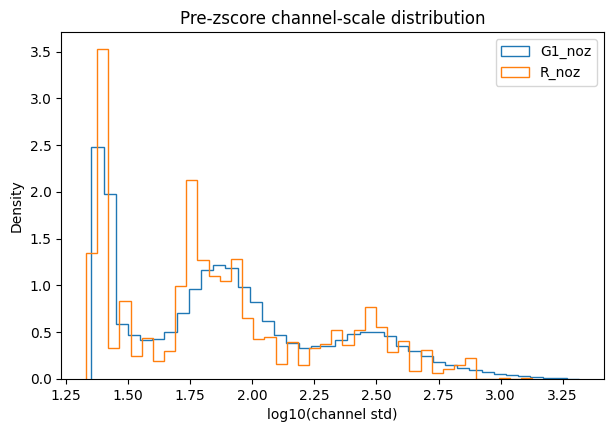

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for domain, group in stats.groupby("domain"):
    ax.hist(
        np.log10(group["std"].to_numpy()),
        bins=40,
        histtype="step",
        density=True,
        label=domain,
    )

ax.set_xlabel("log10(channel std)")
ax.set_ylabel("Density")
ax.set_title("Pre-zscore channel-scale distribution")
ax.legend()
plt.show()


## Paired G1/R contract for the pilot

The same manifest rows must remain paired across the two M11.9 domains.


In [5]:
with h5py.File(G1_PATH, "r") as g1, h5py.File(R_PATH, "r") as rr:
    complete = (
        (g1["status"][:] == 1)
        & (rr["status"][:] == 1)
    )
    idx = np.flatnonzero(complete)

    g1_ids = g1["source_id"].asstr()[idx]
    r_ids = rr["source_id"].asstr()[idx]

    checks = {
        "n_paired": len(idx),
        "source_id_match": np.array_equal(g1_ids, r_ids),
        "manifest_index_match": np.array_equal(
            g1["manifest_index"][idx],
            rr["manifest_index"][idx],
        ),
        "y_match": np.array_equal(
            g1["y"][idx],
            rr["y"][idx],
        ),
        "distance_match": np.allclose(
            g1["distance_mpc"][idx],
            rr["distance_mpc"][idx],
            rtol=0.0,
            atol=1e-10,
        ),
        "G1_finite": np.isfinite(g1["X"][idx]).all(),
        "R_finite": np.isfinite(rr["X"][idx]).all(),
    }

checks


{'n_paired': 26000,
 'source_id_match': True,
 'manifest_index_match': True,
 'y_match': True,
 'distance_match': True,
 'G1_finite': np.True_,
 'R_finite': np.True_}

## Acceptance criterion before full 26k generation

Proceed to the full M11.9 generation if:

- the generator completes the pilot;
- G1/R pairing remains exact;
- all processed inputs are finite;
- the HDF5 representation is marked `processed_pre_zscore`;
- the inputs are visibly **not** forced to zero mean / unit standard deviation.

No further generation diagnostics are required at this stage.



---

# M11.9 — Final 2×2 evaluation: no-z vs M11.6 z-score

The generation, training and 2×2 prediction stages are now complete.

Training summary:

| domain | best epoch | best validation loss |
|---|---:|---:|
| G1_noz | 88 | 0.209647 |
| R_noz | 136 | 0.211105 |

The final scientific question is now tested directly:

$$
\boxed{
\text{Does removing the per-sample/per-detector z-score reveal a G1}\leftrightarrow\text{R domain gap?}
}
$$

We compare the paired 2×2 matrices from:

- **M11.6**: processed inputs + per-sample/per-detector z-score.
- **M11.9**: the same processed inputs before that z-score.

For each label we report RMSE, MAE, bias and $R^2$, together with

$$
D_{A\to B}
=
\frac{\mathrm{RMSE}_{A\to B}}
{\mathrm{RMSE}_{A\to A}}.
$$

The central comparison is

$$
\Delta D_{G1\to R}
=
D^{\mathrm{no-z}}_{G1\to R}
-
D^{z}_{G1\to R},
$$

and analogously for $R\to G1$.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")

M116_DIR = DATA_ROOT / "results" / "m11_6_domains"
M119_DIR = DATA_ROOT / "results" / "m11_9_noz_domains"

FILES_Z = {
    ("G1", "G1"): M116_DIR / "m11_6_G1_to_G1_test_predictions_embeddings.npz",
    ("G1", "R"):  M116_DIR / "m11_6_G1_to_R_test_predictions_embeddings.npz",
    ("R", "G1"):  M116_DIR / "m11_6_R_to_G1_test_predictions_embeddings.npz",
    ("R", "R"):   M116_DIR / "m11_6_R_to_R_test_predictions_embeddings.npz",
}

FILES_NOZ = {
    ("G1", "G1"): M119_DIR / "m11_9_G1_to_G1_noz_test_predictions_embeddings.npz",
    ("G1", "R"):  M119_DIR / "m11_9_G1_to_R_noz_test_predictions_embeddings.npz",
    ("R", "G1"):  M119_DIR / "m11_9_R_to_G1_noz_test_predictions_embeddings.npz",
    ("R", "R"):   M119_DIR / "m11_9_R_to_R_noz_test_predictions_embeddings.npz",
}

for label, mapping in [("M11.6 z-score", FILES_Z), ("M11.9 no-z", FILES_NOZ)]:
    print(f"\n{label}")
    for pair, path in mapping.items():
        print(pair, "->", path.name, "| exists:", path.exists())



M11.6 z-score
('G1', 'G1') -> m11_6_G1_to_G1_test_predictions_embeddings.npz | exists: True
('G1', 'R') -> m11_6_G1_to_R_test_predictions_embeddings.npz | exists: True
('R', 'G1') -> m11_6_R_to_G1_test_predictions_embeddings.npz | exists: True
('R', 'R') -> m11_6_R_to_R_test_predictions_embeddings.npz | exists: True

M11.9 no-z
('G1', 'G1') -> m11_9_G1_to_G1_noz_test_predictions_embeddings.npz | exists: True
('G1', 'R') -> m11_9_G1_to_R_noz_test_predictions_embeddings.npz | exists: True
('R', 'G1') -> m11_9_R_to_G1_noz_test_predictions_embeddings.npz | exists: True
('R', 'R') -> m11_9_R_to_R_noz_test_predictions_embeddings.npz | exists: True



## Load contract and paired-test integrity

The predictor stores `pred_test` and `y_test` in standardized label units, so both are converted back to physical units with the saved train-only scaler:

$$
y_{\rm phys}=y_{\rm std}\,\sigma_{\rm train}+\mu_{\rm train}.
$$

Before computing metrics, verify that all four cells within each experiment use the same test indices and physical targets.


In [2]:

LABELS = ["chirp_mass", "total_mass", "chi_eff"]

def load_prediction_file(path):
    d = np.load(path, allow_pickle=True)

    pred_std = np.asarray(d["pred_test"], dtype=np.float64)
    y_std = np.asarray(d["y_test"], dtype=np.float64)
    idx = np.asarray(d["idx_test"], dtype=np.int64)

    y_mean = np.asarray(d["y_mean"], dtype=np.float64)
    y_scale = np.asarray(d["y_std"], dtype=np.float64)

    label_names = [str(x) for x in d["label_names"].tolist()]

    pred_phys = pred_std * y_scale + y_mean
    y_phys = y_std * y_scale + y_mean

    return {
        "pred_std": pred_std,
        "y_std": y_std,
        "pred_phys": pred_phys,
        "y_phys": y_phys,
        "idx": idx,
        "y_mean": y_mean,
        "y_scale": y_scale,
        "label_names": label_names,
        "path": path,
    }

loaded_z = {pair: load_prediction_file(path) for pair, path in FILES_Z.items()}
loaded_noz = {pair: load_prediction_file(path) for pair, path in FILES_NOZ.items()}

def integrity_report(loaded):
    ref = loaded[("G1", "G1")]

    rows = []
    for pair, item in loaded.items():
        rows.append({
            "train": pair[0],
            "test": pair[1],
            "n": len(item["idx"]),
            "idx_match": np.array_equal(item["idx"], ref["idx"]),
            "y_phys_match": np.allclose(
                item["y_phys"], ref["y_phys"], rtol=0.0, atol=1e-10
            ),
            "scaler_mean_match": np.allclose(
                item["y_mean"], ref["y_mean"], rtol=0.0, atol=1e-12
            ),
            "scaler_std_match": np.allclose(
                item["y_scale"], ref["y_scale"], rtol=0.0, atol=1e-12
            ),
        })
    return pd.DataFrame(rows)

print("M11.6")
display(integrity_report(loaded_z))

print("M11.9")
display(integrity_report(loaded_noz))

# Cross-experiment test-pairing contract.
z_ref = loaded_z[("G1", "G1")]
noz_ref = loaded_noz[("G1", "G1")]

cross_contract = {
    "idx_match_z_vs_noz": np.array_equal(z_ref["idx"], noz_ref["idx"]),
    "y_phys_match_z_vs_noz": np.allclose(
        z_ref["y_phys"], noz_ref["y_phys"], rtol=0.0, atol=1e-10
    ),
    "scaler_mean_match": np.allclose(
        z_ref["y_mean"], noz_ref["y_mean"], rtol=0.0, atol=1e-12
    ),
    "scaler_std_match": np.allclose(
        z_ref["y_scale"], noz_ref["y_scale"], rtol=0.0, atol=1e-12
    ),
}

cross_contract


M11.6


,train,test,n,idx_match,y_phys_match,scaler_mean_match,scaler_std_match
0,G1,G1,2000,True,True,True,True
1,G1,R,2000,True,True,True,True
2,R,G1,2000,True,True,True,True
3,R,R,2000,True,True,True,True


M11.9


,train,test,n,idx_match,y_phys_match,scaler_mean_match,scaler_std_match
0,G1,G1,2000,True,True,True,True
1,G1,R,2000,True,True,True,True
2,R,G1,2000,True,True,True,True
3,R,R,2000,True,True,True,True


{'idx_match_z_vs_noz': True,
 'y_phys_match_z_vs_noz': True,
 'scaler_mean_match': True,
 'scaler_std_match': True}


## Physical regression metrics

For each label:

$$
\mathrm{RMSE}
=
\sqrt{\frac{1}{N}\sum_i(\hat y_i-y_i)^2},
$$

$$
\mathrm{MAE}
=
\frac{1}{N}\sum_i|\hat y_i-y_i|,
$$

$$
\mathrm{bias}
=
\frac{1}{N}\sum_i(\hat y_i-y_i).
$$

The columns `q50`, `q90` and `q95` are the 50th, 90th and 95th percentiles of
absolute physical prediction error, `abs(pred_phys - y_phys)`, for each label.
They use NumPy's default linear quantile interpolation.

All values below are in physical units.


In [3]:

def regression_metrics_phys(y_true, y_pred, labels=LABELS):
    rows = []

    for j, label in enumerate(labels):
        yt = y_true[:, j]
        yp = y_pred[:, j]
        residual = yp - yt

        rmse = np.sqrt(np.mean(residual**2))
        mae = np.mean(np.abs(residual))
        bias = np.mean(residual)
        q50, q90, q95 = np.quantile(np.abs(residual), [0.50, 0.90, 0.95])

        ss_res = np.sum((yt - yp)**2)
        ss_tot = np.sum((yt - np.mean(yt))**2)
        r2 = 1.0 - ss_res / ss_tot

        rows.append({
            "label": label,
            "RMSE": float(rmse),
            "MAE": float(mae),
            "bias": float(bias),
            "R2": float(r2),
            "q50": float(q50),
            "q90": float(q90),
            "q95": float(q95),
        })

    return pd.DataFrame(rows)

def metrics_table(loaded, regime):
    rows = []

    for (train_dom, test_dom), item in loaded.items():
        m = regression_metrics_phys(
            item["y_phys"],
            item["pred_phys"],
            labels=item["label_names"],
        )

        for _, r in m.iterrows():
            rows.append({
                "regime": regime,
                "train": train_dom,
                "test": test_dom,
                "label": r["label"],
                "RMSE": r["RMSE"],
                "MAE": r["MAE"],
                "bias": r["bias"],
                "R2": r["R2"],
                "q50": r["q50"],
                "q90": r["q90"],
                "q95": r["q95"],
            })

    return pd.DataFrame(rows)

metrics_z = metrics_table(loaded_z, "zscore")
metrics_noz = metrics_table(loaded_noz, "no_zscore")

metrics_all = pd.concat(
    [metrics_z, metrics_noz],
    ignore_index=True,
)

display(
    metrics_all.sort_values(
        ["label", "regime", "train", "test"]
    ).reset_index(drop=True)
)


,regime,train,test,label,RMSE,MAE,bias,R2,q50,q90,q95
0,no_zscore,G1,G1,chi_eff,0.249424,0.189454,-0.005885,0.690995,0.146313,0.405828,0.522962
1,no_zscore,G1,R,chi_eff,0.250644,0.191337,-0.010205,0.687964,0.153525,0.404433,0.492915
2,no_zscore,R,G1,chi_eff,0.252473,0.191123,-0.008322,0.683395,0.154063,0.414112,0.513256
3,no_zscore,R,R,chi_eff,0.248131,0.186392,0.009036,0.694190,0.147885,0.387890,0.504045
4,zscore,G1,G1,chi_eff,0.248731,0.191540,-0.014310,0.692709,0.153715,0.399054,0.492804
5,zscore,G1,R,chi_eff,0.249368,0.188335,-0.016828,0.691134,0.151327,0.399587,0.502174
6,zscore,R,G1,chi_eff,0.254250,0.195843,0.035455,0.678921,0.156230,0.413603,0.503390
7,zscore,R,R,chi_eff,0.254357,0.191227,0.045054,0.678652,0.148561,0.414389,0.513873
8,no_zscore,G1,G1,chirp_mass,7.394631,5.173804,0.146115,0.796142,3.596192,11.390742,15.025597
9,no_zscore,G1,R,chirp_mass,7.462712,5.201404,0.220752,0.792371,3.669644,11.482774,15.346836



## 2×2 RMSE matrices

These matrices show absolute regression performance. The diagonal is in-domain performance; the off-diagonal cells are cross-domain transfer.


In [4]:

def rmse_matrix(metrics_df, label):
    sub = metrics_df[metrics_df["label"] == label]

    return (
        sub.pivot(index="train", columns="test", values="RMSE")
        .reindex(index=["G1", "R"], columns=["G1", "R"])
    )

for label in LABELS:
    print("\n" + "=" * 72)
    print(label)
    print("=" * 72)

    print("\nM11.6 — z-score")
    display(rmse_matrix(metrics_z, label))

    print("M11.9 — no z-score")
    display(rmse_matrix(metrics_noz, label))



chirp_mass

M11.6 — z-score


test,G1,R
train,,
G1,7.495503,7.571356
R,7.524520,7.373054


M11.9 — no z-score


test,G1,R
train,,
G1,7.394631,7.462712
R,7.130383,6.984491



total_mass

M11.6 — z-score


...

test,G1,R
train,,
G1,13.688825,13.955757
R,13.312223,13.038205



chi_eff

M11.6 — z-score


test,G1,R
train,,
G1,0.248731,0.249368
R,0.254250,0.254357


M11.9 — no z-score


test,G1,R
train,,
G1,0.249424,0.250644
R,0.252473,0.248131



## Domain-transfer factors $D$

For a model trained on domain $A$,

$$
D_{A\to B}
=
\frac{\mathrm{RMSE}_{A\to B}}
{\mathrm{RMSE}_{A\to A}}.
$$

Therefore:

- $D=1$: no cross-domain degradation relative to the model's own domain.
- $D>1$: worse transfer to the other domain.
- $D<1$: the cross-domain target is easier for that trained model than its own-domain test set.


In [5]:

def compute_D_table(metrics_df):
    rows = []

    for label in LABELS:
        sub = metrics_df[metrics_df["label"] == label]

        for train_dom in ["G1", "R"]:
            own = float(
                sub[
                    (sub["train"] == train_dom)
                    & (sub["test"] == train_dom)
                ]["RMSE"].iloc[0]
            )

            for test_dom in ["G1", "R"]:
                rmse = float(
                    sub[
                        (sub["train"] == train_dom)
                        & (sub["test"] == test_dom)
                    ]["RMSE"].iloc[0]
                )

                rows.append({
                    "label": label,
                    "train": train_dom,
                    "test": test_dom,
                    "RMSE": rmse,
                    "D": rmse / own,
                })

    return pd.DataFrame(rows)

D_z = compute_D_table(metrics_z)
D_noz = compute_D_table(metrics_noz)

for label in LABELS:
    print("\n" + "=" * 72)
    print(label)
    print("=" * 72)

    print("\nM11.6 — z-score")
    display(
        D_z[D_z["label"] == label]
        .pivot(index="train", columns="test", values="D")
        .reindex(index=["G1", "R"], columns=["G1", "R"])
    )

    print("M11.9 — no z-score")
    display(
        D_noz[D_noz["label"] == label]
        .pivot(index="train", columns="test", values="D")
        .reindex(index=["G1", "R"], columns=["G1", "R"])
    )



chirp_mass

M11.6 — z-score


test,G1,R
train,,
G1,1.000000,1.01012
R,1.020543,1.00000


M11.9 — no z-score


test,G1,R
train,,
G1,1.000000,1.009207
R,1.020888,1.000000



total_mass

M11.6 — z-score


...

test,G1,R
train,,
G1,1.000000,1.0195
R,1.021017,1.0000



chi_eff

M11.6 — z-score


test,G1,R
train,,
G1,1.000000,1.002559
R,0.999582,1.000000


M11.9 — no z-score


test,G1,R
train,,
G1,1.000000,1.004891
R,1.017497,1.000000



## Direct M11.6 vs M11.9 comparison

The main causal diagnostic is whether the cross-domain transfer factors change when the z-score is removed:

$$
\Delta D_{G1\to R}
=
D^{\mathrm{no-z}}_{G1\to R}
-
D^{z}_{G1\to R},
$$

$$
\Delta D_{R\to G1}
=
D^{\mathrm{no-z}}_{R\to G1}
-
D^{z}_{R\to G1}.
$$

We also compare absolute in-domain RMSE to distinguish **domain similarity** from **optimization / representation quality**.


In [6]:

comparison_rows = []

for label in LABELS:
    for train_dom, test_dom in [("G1", "G1"), ("G1", "R"), ("R", "G1"), ("R", "R")]:
        rz = metrics_z[
            (metrics_z["label"] == label)
            & (metrics_z["train"] == train_dom)
            & (metrics_z["test"] == test_dom)
        ].iloc[0]

        rn = metrics_noz[
            (metrics_noz["label"] == label)
            & (metrics_noz["train"] == train_dom)
            & (metrics_noz["test"] == test_dom)
        ].iloc[0]

        dz = D_z[
            (D_z["label"] == label)
            & (D_z["train"] == train_dom)
            & (D_z["test"] == test_dom)
        ]["D"].iloc[0]

        dn = D_noz[
            (D_noz["label"] == label)
            & (D_noz["train"] == train_dom)
            & (D_noz["test"] == test_dom)
        ]["D"].iloc[0]

        comparison_rows.append({
            "label": label,
            "train": train_dom,
            "test": test_dom,
            "RMSE_z": rz["RMSE"],
            "RMSE_noz": rn["RMSE"],
            "RMSE_noz_vs_z_pct": 100.0 * (rn["RMSE"] / rz["RMSE"] - 1.0),
            "D_z": dz,
            "D_noz": dn,
            "Delta_D_noz_minus_z": dn - dz,
        })

comparison = pd.DataFrame(comparison_rows)

display(
    comparison.sort_values(
        ["label", "train", "test"]
    ).reset_index(drop=True)
)


,label,train,test,RMSE_z,RMSE_noz,RMSE_noz_vs_z_pct,D_z,D_noz,Delta_D_noz_minus_z
0,chi_eff,G1,G1,0.248731,0.249424,0.278599,1.000000,1.000000,0.000000
1,chi_eff,G1,R,0.249368,0.250644,0.511851,1.002559,1.004891,0.002332
2,chi_eff,R,G1,0.254250,0.252473,-0.699134,0.999582,1.017497,0.017915
3,chi_eff,R,R,0.254357,0.248131,-2.447478,1.000000,1.000000,0.000000
4,chirp_mass,G1,G1,7.495503,7.394631,-1.345757,1.000000,1.000000,0.000000
5,chirp_mass,G1,R,7.571356,7.462712,-1.434940,1.010120,1.009207,-0.000913
6,chirp_mass,R,G1,7.524520,7.130383,-5.238033,1.020543,1.020888,0.000345
7,chirp_mass,R,R,7.373054,6.984491,-5.270039,1.000000,1.000000,0.000000
8,total_mass,G1,G1,14.098742,13.688825,-2.907476,1.000000,1.000000,0.000000
9,total_mass,G1,R,14.565664,13.955757,-4.187293,1.033118,1.019500,-0.013618


In [7]:

cross_only = comparison[
    ((comparison["train"] == "G1") & (comparison["test"] == "R"))
    | ((comparison["train"] == "R") & (comparison["test"] == "G1"))
].copy()

print("Central M11.9 cross-domain comparison")
display(
    cross_only[
        [
            "label",
            "train",
            "test",
            "D_z",
            "D_noz",
            "Delta_D_noz_minus_z",
            "RMSE_z",
            "RMSE_noz",
            "RMSE_noz_vs_z_pct",
        ]
    ].reset_index(drop=True)
)


Central M11.9 cross-domain comparison


,label,train,test,D_z,D_noz,Delta_D_noz_minus_z,RMSE_z,RMSE_noz,RMSE_noz_vs_z_pct
0,chirp_mass,G1,R,1.010120,1.009207,-0.000913,7.571356,7.462712,-1.434940
1,chirp_mass,R,G1,1.020543,1.020888,0.000345,7.524520,7.130383,-5.238033
2,total_mass,G1,R,1.033118,1.019500,-0.013618,14.565664,13.955757,-4.187293
3,total_mass,R,G1,0.998518,1.021017,0.022498,14.091666,13.312223,-5.531237
4,chi_eff,G1,R,1.002559,1.004891,0.002332,0.249368,0.250644,0.511851
5,chi_eff,R,G1,0.999582,1.017497,0.017915,0.254250,0.252473,-0.699134



## Compact visual comparison

The following plots are deliberately limited to the quantities that answer the M11.9 question directly.


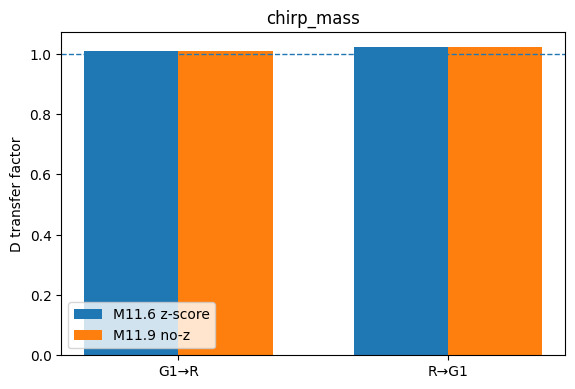

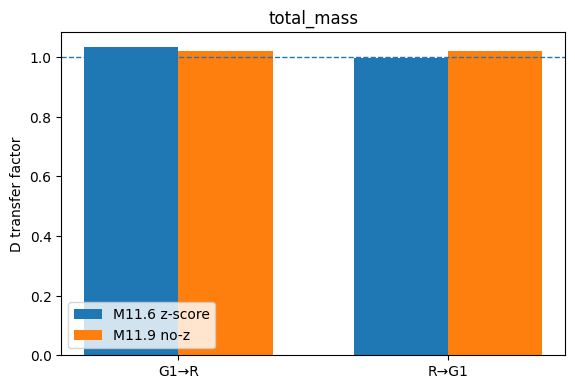

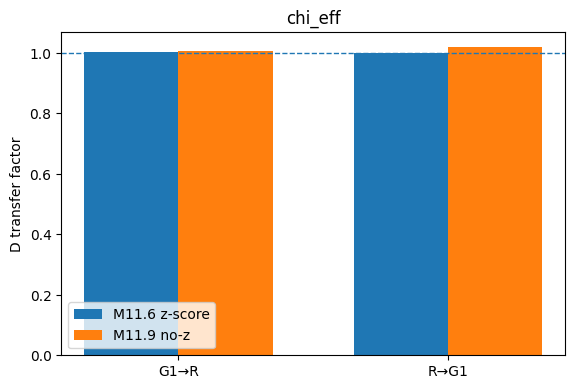

In [8]:

for label in LABELS:
    sub = comparison[
        (comparison["label"] == label)
        & (
            ((comparison["train"] == "G1") & (comparison["test"] == "R"))
            | ((comparison["train"] == "R") & (comparison["test"] == "G1"))
        )
    ].copy()

    names = [
        f"{r.train}→{r.test}"
        for r in sub.itertuples()
    ]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.bar(x - width/2, sub["D_z"], width, label="M11.6 z-score")
    ax.bar(x + width/2, sub["D_noz"], width, label="M11.9 no-z")

    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel("D transfer factor")
    ax.set_title(label)
    ax.legend()
    plt.show()



## Automatic result summary

This cell prints a compact numerical summary. Scientific interpretation should remain tied to the observed magnitude of $D$, $\Delta D$, and the absolute RMSE change.


In [9]:

summary_rows = []

for label in LABELS:
    g1r_z = float(
        D_z[
            (D_z["label"] == label)
            & (D_z["train"] == "G1")
            & (D_z["test"] == "R")
        ]["D"].iloc[0]
    )
    g1r_n = float(
        D_noz[
            (D_noz["label"] == label)
            & (D_noz["train"] == "G1")
            & (D_noz["test"] == "R")
        ]["D"].iloc[0]
    )

    rg1_z = float(
        D_z[
            (D_z["label"] == label)
            & (D_z["train"] == "R")
            & (D_z["test"] == "G1")
        ]["D"].iloc[0]
    )
    rg1_n = float(
        D_noz[
            (D_noz["label"] == label)
            & (D_noz["train"] == "R")
            & (D_noz["test"] == "G1")
        ]["D"].iloc[0]
    )

    summary_rows.append({
        "label": label,
        "D_z_G1_to_R": g1r_z,
        "D_noz_G1_to_R": g1r_n,
        "DeltaD_G1_to_R": g1r_n - g1r_z,
        "D_z_R_to_G1": rg1_z,
        "D_noz_R_to_G1": rg1_n,
        "DeltaD_R_to_G1": rg1_n - rg1_z,
    })

summary_D = pd.DataFrame(summary_rows)
display(summary_D)


,label,D_z_G1_to_R,D_noz_G1_to_R,DeltaD_G1_to_R,D_z_R_to_G1,D_noz_R_to_G1,DeltaD_R_to_G1
0,chirp_mass,1.010120,1.009207,-0.000913,1.020543,1.020888,0.000345
1,total_mass,1.033118,1.019500,-0.013618,0.998518,1.021017,0.022498
2,chi_eff,1.002559,1.004891,0.002332,0.999582,1.017497,0.017915



## Interpretation framework

Use the final numerical results with the following logic:

### Case A — $D^{\mathrm{no-z}}\approx 1$ and $\Delta D\approx 0$

The G1/R proximity seen in M11.6 is **not primarily an artefact of the per-sample/per-detector z-score**. The empirical-PSD Gaussian domain and the real-noise domain remain close for this regression task even when detector/sample scale information is preserved.

If absolute RMSE is nevertheless worse without z-score, then the z-score is acting mainly as an **optimization / representation stabilizer**, rather than as the mechanism that closes the G1/R domain gap.

### Case B — $D^{\mathrm{no-z}}$ grows substantially above 1

Removing the z-score exposes a domain gap that was suppressed in M11.6. Scale and/or amplitude information removed by the z-score then contributes materially to G1/R separability.

### Case C — asymmetric behaviour

If only one of $G1\to R$ or $R\to G1$ degrades, then the two domains are not equivalent in a symmetric sense. The next useful stage would be targeted representation analysis rather than immediately trying additional normalizations.

No embeddings, domain classifier, PCA/UMAP or alternative normalization sweep is required unless the 2×2 regression result motivates it.


> Bajo el pipeline actual de whitening con PSD empírica, target SNR controlado y la población BBH estudiada, el ruido gaussiano generado a partir de la PSD empírica reproduce de forma suficientemente cercana el dominio real para la tarea de regresión de chirp_mass, total_mass y chi_eff. El uso de ruido real no aporta una mejora clara que justifique su mayor complejidad operativa.